### Reading in Data, Basic Queries

In [4]:
import pandas as pd

In [5]:
"""
Post the following to the discussion board:

Attach your visualization.
Explain the method you used to create the visualization.
Share what library you used.
Describe the results you found and what they tell you about the dataset you chose.

"""

'\nPost the following to the discussion board:\n\nAttach your visualization.\nExplain the method you used to create the visualization.\nShare what library you used.\nDescribe the results you found and what they tell you about the dataset you chose.\n\n'

In [6]:
df = pd.read_csv("../data/gdp.csv")

In [7]:
df.head()

,Entity,Code,Year,GDP (constant 2010 US$)
0,Afghanistan,AFG,2002,8.013233e+09
1,Afghanistan,AFG,2003,8.689884e+09
2,Afghanistan,AFG,2004,8.781610e+09
3,Afghanistan,AFG,2005,9.762979e+09
4,Afghanistan,AFG,2006,1.030523e+10


In [8]:
df.tail()

,Entity,Code,Year,GDP (constant 2010 US$)
8864,Zimbabwe,ZWE,2013,1.418193e+10
8865,Zimbabwe,ZWE,2014,1.448359e+10
8866,Zimbabwe,ZWE,2015,1.472830e+10
8867,Zimbabwe,ZWE,2016,1.481899e+10
8868,Zimbabwe,ZWE,2017,1.532981e+10


In [9]:
df.sample(5)

,Entity,Code,Year,GDP (constant 2010 US$)
5195,Mauritania,MRT,1967,1.192042e+09
6862,Saint Lucia,LCA,2015,1.465619e+09
6089,Oman,OMN,1990,2.700691e+10
7463,South Korea,KOR,1986,2.453264e+11
4093,Israel,ISR,2017,2.973961e+11


In [10]:
df

,Entity,Code,Year,GDP (constant 2010 US$)
0,Afghanistan,AFG,2002,8.013233e+09
1,Afghanistan,AFG,2003,8.689884e+09
2,Afghanistan,AFG,2004,8.781610e+09
3,Afghanistan,AFG,2005,9.762979e+09
4,Afghanistan,AFG,2006,1.030523e+10
...,...,...,...,...
8864,Zimbabwe,ZWE,2013,1.418193e+10
8865,Zimbabwe,ZWE,2014,1.448359e+10
8866,Zimbabwe,ZWE,2015,1.472830e+10
8867,Zimbabwe,ZWE,2016,1.481899e+10


In [11]:
df["gdp"] = df["GDP (constant 2010 US$)"] / 1_000_000_000

In [12]:
df

,Entity,Code,Year,GDP (constant 2010 US$),gdp
0,Afghanistan,AFG,2002,8.013233e+09,8.013233
1,Afghanistan,AFG,2003,8.689884e+09,8.689884
2,Afghanistan,AFG,2004,8.781610e+09,8.781610
3,Afghanistan,AFG,2005,9.762979e+09,9.762979
4,Afghanistan,AFG,2006,1.030523e+10,10.305228
...,...,...,...,...,...
8864,Zimbabwe,ZWE,2013,1.418193e+10,14.181927
8865,Zimbabwe,ZWE,2014,1.448359e+10,14.483588
8866,Zimbabwe,ZWE,2015,1.472830e+10,14.728302
8867,Zimbabwe,ZWE,2016,1.481899e+10,14.818986


In [13]:
# See the GDP of only China
df[df["Entity"] == "China"].head(10)

,Entity,Code,Year,GDP (constant 2010 US$),gdp
1726,China,CHN,1960,1.279381e+11,127.938142
1727,China,CHN,1961,9.304941e+10,93.049411
1728,China,CHN,1962,8.785725e+10,87.857254
1729,China,CHN,1963,9.690655e+10,96.906551
1730,China,CHN,1964,1.145242e+11,114.524162
1731,China,CHN,1965,1.339360e+11,133.936007
1732,China,CHN,1966,1.482002e+11,148.200192
1733,China,CHN,1967,1.396490e+11,139.649041
1734,China,CHN,1968,1.339234e+11,133.923430
1735,China,CHN,1969,1.566101e+11,156.610060


In [14]:
df["Entity"] == "China"[:10] # this is a Series

0       False
1       False
2       False
3       False
4       False
        ...  
8864    False
8865    False
8866    False
8867    False
8868    False
Name: Entity, Length: 8869, dtype: bool

In [15]:
(df["Entity"] == "China").iloc[1775:1790]

1775     True
1776     True
1777     True
1778     True
1779     True
1780     True
1781     True
1782     True
1783     True
1784    False
1785    False
1786    False
1787    False
1788    False
1789    False
Name: Entity, dtype: bool

In [16]:
# GDP of China in 2017 using &
df[(df["Entity"] == "China") & (df["Year"] == 2017)]

,Entity,Code,Year,GDP (constant 2010 US$),gdp
1783,China,CHN,2017,1.016101e+13,10161.012759


In [17]:
# GDP of China in 2017 using query
df.query('Entity == "China" and Year == 2017')

,Entity,Code,Year,GDP (constant 2010 US$),gdp
1783,China,CHN,2017,1.016101e+13,10161.012759


In [18]:
# Seeing GDP only from a list of countries using isin
list_of_countries = ["China", "United States", "India",
                     "Japan", "Germany", "United Kingdom"]
top6 = df[df["Entity"].isin(list_of_countries)]

In [19]:
top6 = df.query("Entity in @list_of_countries and Year == 2017")

### Introducing Our Visualization Libraries

In [20]:
import matplotlib.pyplot as plt

In [21]:
12

12

<Axes: xlabel='Entity', ylabel='gdp'>

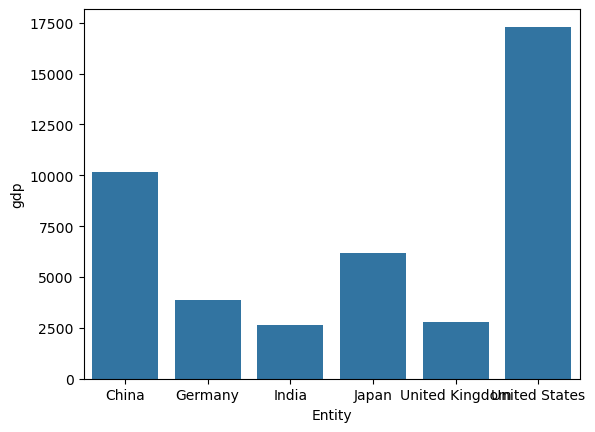

In [22]:
import seaborn as sns
sns.barplot(data = top6, x = "Entity", y = "gdp")

([0, 1, 2, 3, 4, 5],
 [Text(0, 0, 'China'),
  Text(1, 0, 'Germany'),
  Text(2, 0, 'India'),
  Text(3, 0, 'Japan'),
  Text(4, 0, 'United Kingdom'),
  Text(5, 0, 'United States')])

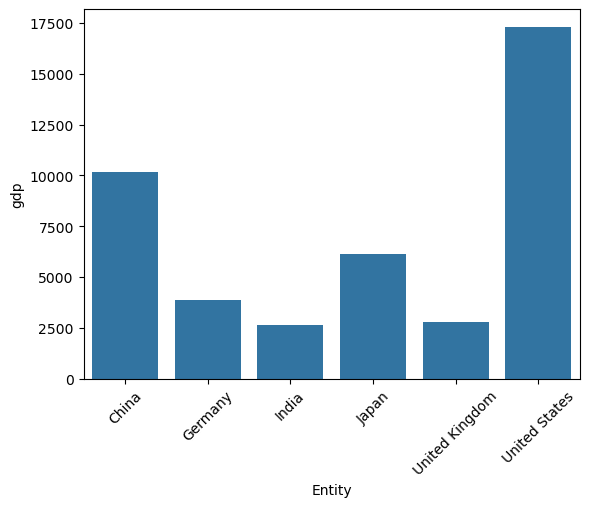

In [23]:
sns.barplot(data = top6, x = "Entity", y = "gdp")
plt.xticks(rotation = 45)

([0, 1, 2, 3, 4, 5],
 [Text(0, 0, 'China'),
  Text(1, 0, 'Germany'),
  Text(2, 0, 'India'),
  Text(3, 0, 'Japan'),
  Text(4, 0, 'United Kingdom'),
  Text(5, 0, 'United States')])

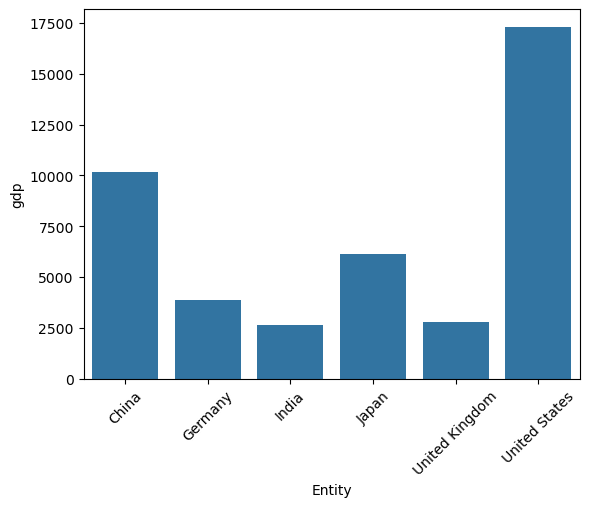

In [24]:
import seaborn as sns
sns.barplot(data = top6, x = "Entity", y = "gdp")
plt.xticks(rotation=45)

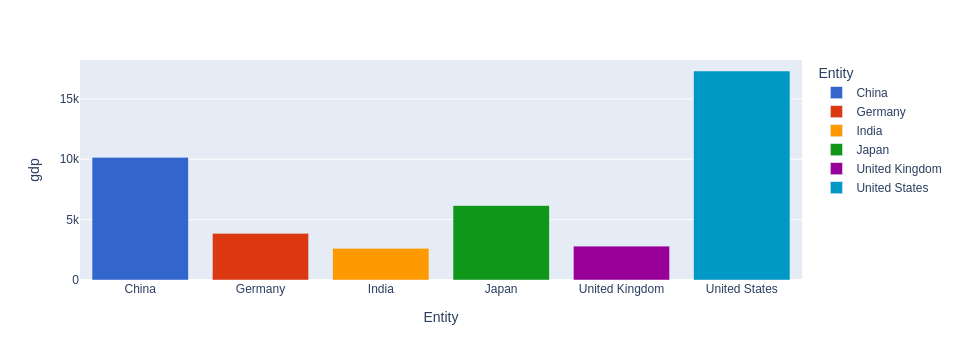

In [25]:
import plotly.express as px

fig = px.bar(top6, x = "Entity", y = "gdp", color = "Entity",
            color_discrete_sequence=px.colors.qualitative.G10)
fig.show()

In [26]:
list_of_countries = ["China", "United States", "India",
                     "Japan", "Germany", "United Kingdom"]
top6_over_time = df[df["Entity"].isin(list_of_countries)]

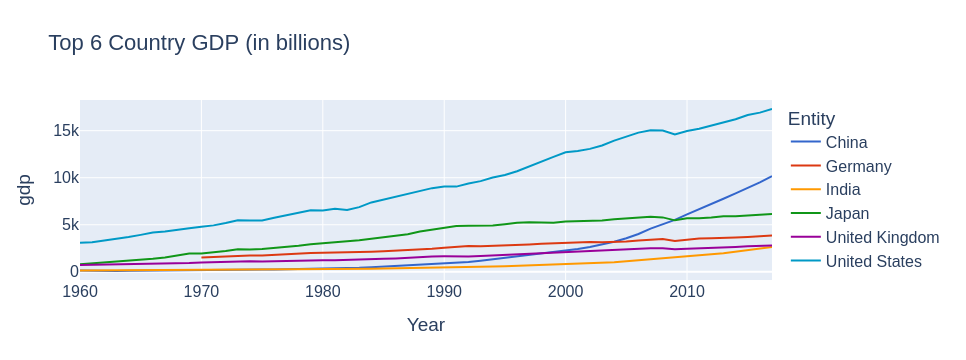

In [27]:
list_of_countries = ["China", "United States", "India",
                     "Japan", "Germany", "United Kingdom"]
top6_over_time = df[df["Entity"].isin(list_of_countries)]
fig = px.line(top6_over_time, x = "Year", y = "gdp", color = "Entity",
            title = "Top 6 Country GDP (in billions)",
            color_discrete_sequence=px.colors.qualitative.G10)
fig.update_layout(font_size = 16)

fig.show()

### Groupby Operations

In [28]:
# What was the total GDP of the world in each year?

In [29]:
df.query("Year == 1960")

,Entity,Code,Year,GDP (constant 2010 US$),gdp
54,Algeria,DZA,1960,2.743440e+10,27.434399
254,Argentina,ARG,1960,1.155739e+11,115.573869
341,Australia,AUS,1960,1.992333e+11,199.233335
399,Austria,AUT,1960,9.183670e+10,91.836703
485,Bahamas,BHS,1960,1.942538e+09,1.942538
...,...,...,...,...,...
8437,United States,USA,1960,3.078071e+12,3078.071080
8509,Uruguay,URY,1960,1.389815e+10,13.898153
8637,Venezuela,VEN,1960,1.014246e+11,101.424598
8753,Zambia,ZMB,1960,4.592976e+09,4.592976


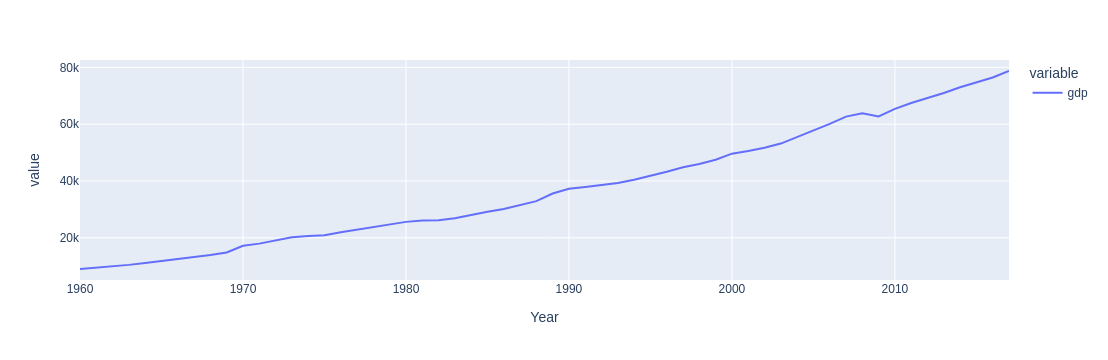

In [111]:
px.line(df.groupby("Year")["gdp"].agg(sum))

In [69]:
# What was the largest GDP of any country in each year?

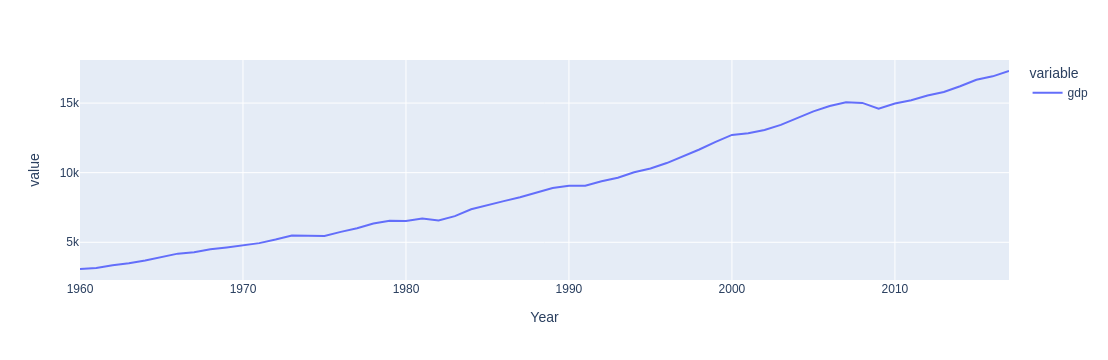

In [70]:
px.line(df.groupby("Year")[["gdp"]].agg(max))

In [71]:
# What was the smallest GDP of any country in each year?

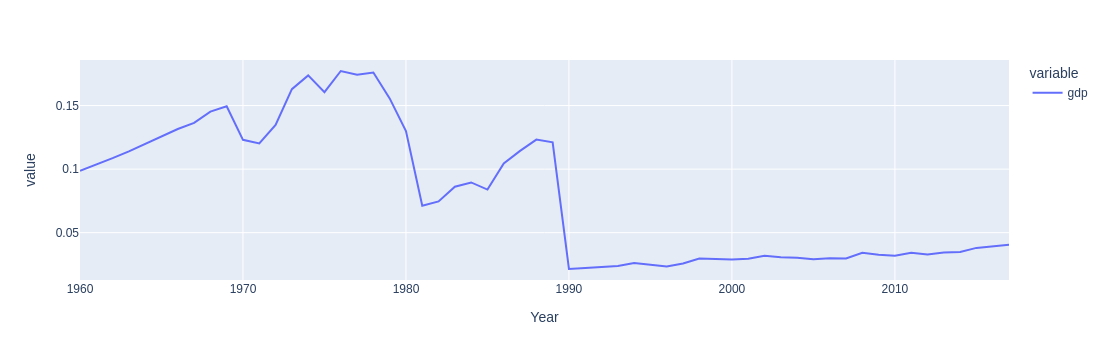

In [72]:
px.line(df.groupby("Year")[["gdp"]].agg(min))

In [73]:
# What was the ratio of the largest to smallest GDP in each year?

In [74]:
largest_gdps = df.groupby("Year")[["gdp"]].agg(max)
smallest_gdps = df.groupby("Year")[["gdp"]].agg(min)

In [75]:
ratio_of_largest_to_smallest = largest_gdps / smallest_gdps

In [76]:
ratio_of_largest_to_smallest

,gdp
Year,
1960,31174.904577
1961,30404.457057
1962,30754.422037
1963,30591.375224
1964,30824.487623
1965,31256.157197
1966,31772.013845
1967,31427.624080
1968,30923.144291


In [77]:
def ratio_of_largest_to_smallest(s):
    largest = max(s)
    smallest = min(s)
    return largest / smallest

In [78]:
 df.groupby("Year")[["gdp"]].agg(ratio_of_largest_to_smallest)

,gdp
Year,
1960,31174.904577
1961,30404.457057
1962,30754.422037
1963,30591.375224
1964,30824.487623
1965,31256.157197
1966,31772.013845
1967,31427.624080
1968,30923.144291


In [79]:
# What was the smallest economy in each year?

In [80]:
df.groupby("Year").agg(min)

,Entity,Code,GDP (constant 2010 US$),gdp
Year,,,,
1960,Algeria,ARG,9.873554e+07,0.098736
1961,Algeria,ARG,1.035660e+08,0.103566
1962,Algeria,ARG,1.086331e+08,0.108633
1963,Algeria,ARG,1.140174e+08,0.114017
1964,Algeria,ARG,1.197181e+08,0.119718
1965,Algeria,ARG,1.256209e+08,0.125621
1966,Algeria,ARG,1.316141e+08,0.131614
1967,Algeria,ARG,1.363827e+08,0.136383
1968,Algeria,ARG,1.452608e+08,0.145261


In [81]:
df.sort_values("gdp")

,Entity,Code,Year,GDP (constant 2010 US$),gdp
8241,Tuvalu,TUV,1990,2.144197e+07,0.021442
8242,Tuvalu,TUV,1991,2.221584e+07,0.022216
8243,Tuvalu,TUV,1992,2.283541e+07,0.022835
8247,Tuvalu,TUV,1996,2.342202e+07,0.023422
8244,Tuvalu,TUV,1993,2.377411e+07,0.023774
...,...,...,...,...,...
8490,United States,USA,2013,1.580286e+13,15802.855301
8491,United States,USA,2014,1.620886e+13,16208.861247
8492,United States,USA,2015,1.667269e+13,16672.691918
8493,United States,USA,2016,1.692033e+13,16920.327942


In [82]:
def get_first_item(s):
    return s.iloc[0]

In [83]:
df.sort_values("gdp").groupby("Year").agg(get_first_item)

,Entity,Code,GDP (constant 2010 US$),gdp
Year,,,,
1960,Belize,BLZ,9.873554e+07,0.098736
1961,Belize,BLZ,1.035660e+08,0.103566
1962,Belize,BLZ,1.086331e+08,0.108633
1963,Belize,BLZ,1.140174e+08,0.114017
1964,Belize,BLZ,1.197181e+08,0.119718
1965,Belize,BLZ,1.256209e+08,0.125621
1966,Belize,BLZ,1.316141e+08,0.131614
1967,Saint Vincent and the Grenadines,VCT,1.363827e+08,0.136383
1968,Saint Vincent and the Grenadines,VCT,1.452608e+08,0.145261


In [84]:
df.sort_values("gdp").groupby("Year").first()

,Entity,Code,GDP (constant 2010 US$),gdp
Year,,,,
1960,Belize,BLZ,9.873554e+07,0.098736
1961,Belize,BLZ,1.035660e+08,0.103566
1962,Belize,BLZ,1.086331e+08,0.108633
1963,Belize,BLZ,1.140174e+08,0.114017
1964,Belize,BLZ,1.197181e+08,0.119718
1965,Belize,BLZ,1.256209e+08,0.125621
1966,Belize,BLZ,1.316141e+08,0.131614
1967,Saint Vincent and the Grenadines,VCT,1.363827e+08,0.136383
1968,Saint Vincent and the Grenadines,VCT,1.452608e+08,0.145261


In [85]:
df[df["Entity"] == "Tuvalu"]

,Entity,Code,Year,GDP (constant 2010 US$),gdp
8241,Tuvalu,TUV,1990,2.144197e+07,0.021442
8242,Tuvalu,TUV,1991,2.221584e+07,0.022216
8243,Tuvalu,TUV,1992,2.283541e+07,0.022835
8244,Tuvalu,TUV,1993,2.377411e+07,0.023774
8245,Tuvalu,TUV,1994,2.621891e+07,0.026219
8246,Tuvalu,TUV,1995,2.490680e+07,0.024907
8247,Tuvalu,TUV,1996,2.342202e+07,0.023422
8248,Tuvalu,TUV,1997,2.576498e+07,0.025765
8249,Tuvalu,TUV,1998,2.975886e+07,0.029759
8250,Tuvalu,TUV,1999,2.929350e+07,0.029293


In [86]:
# What fraction of world GDP did each country generate each year?

In [87]:
df

,Entity,Code,Year,GDP (constant 2010 US$),gdp
0,Afghanistan,AFG,2002,8.013233e+09,8.013233
1,Afghanistan,AFG,2003,8.689884e+09,8.689884
2,Afghanistan,AFG,2004,8.781610e+09,8.781610
3,Afghanistan,AFG,2005,9.762979e+09,9.762979
4,Afghanistan,AFG,2006,1.030523e+10,10.305228
...,...,...,...,...,...
8864,Zimbabwe,ZWE,2013,1.418193e+10,14.181927
8865,Zimbabwe,ZWE,2014,1.448359e+10,14.483588
8866,Zimbabwe,ZWE,2015,1.472830e+10,14.728302
8867,Zimbabwe,ZWE,2016,1.481899e+10,14.818986


In [88]:
total_gdp = df[["GDP (constant 2010 US$)","gdp"]]

total_gdp

,GDP (constant 2010 US$),gdp
0,8.013233e+09,8.013233
1,8.689884e+09,8.689884
2,8.781610e+09,8.781610
3,9.762979e+09,9.762979
4,1.030523e+10,10.305228
...,...,...
8864,1.418193e+10,14.181927
8865,1.448359e+10,14.483588
8866,1.472830e+10,14.728302
8867,1.481899e+10,14.818986


In [89]:
chinese_gdp_indexed_by_year = df.query('Entity == "China"').set_index("Year")

In [90]:
chinese_gdp_indexed_by_year

,Entity,Code,GDP (constant 2010 US$),gdp
Year,,,,
1960,China,CHN,1.279381e+11,127.938142
1961,China,CHN,9.304941e+10,93.049411
1962,China,CHN,8.785725e+10,87.857254
1963,China,CHN,9.690655e+10,96.906551
1964,China,CHN,1.145242e+11,114.524162
1965,China,CHN,1.339360e+11,133.936007
1966,China,CHN,1.482002e+11,148.200192
1967,China,CHN,1.396490e+11,139.649041
1968,China,CHN,1.339234e+11,133.923430


In [91]:
df.set_index("Year")

,Entity,Code,GDP (constant 2010 US$),gdp
Year,,,,
2002,Afghanistan,AFG,8.013233e+09,8.013233
2003,Afghanistan,AFG,8.689884e+09,8.689884
2004,Afghanistan,AFG,8.781610e+09,8.781610
2005,Afghanistan,AFG,9.762979e+09,9.762979
2006,Afghanistan,AFG,1.030523e+10,10.305228
...,...,...,...,...
2013,Zimbabwe,ZWE,1.418193e+10,14.181927
2014,Zimbabwe,ZWE,1.448359e+10,14.483588
2015,Zimbabwe,ZWE,1.472830e+10,14.728302


In [92]:
df.set_index("Year") / total_gdp

,Code,Entity,GDP (constant 2010 US$),gdp
Year,,,,
0,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN
...,...,...,...,...
8864,NaN,NaN,NaN,NaN
8865,NaN,NaN,NaN,NaN
8866,NaN,NaN,NaN,NaN


In [93]:
df_indexed_by_year_and_entity = df.set_index(["Year", "Entity"])
df_indexed_by_year_and_entity

,,Code,GDP (constant 2010 US$),gdp
Year,Entity,,,
2002,Afghanistan,AFG,8.013233e+09,8.013233
2003,Afghanistan,AFG,8.689884e+09,8.689884
2004,Afghanistan,AFG,8.781610e+09,8.781610
2005,Afghanistan,AFG,9.762979e+09,9.762979
2006,Afghanistan,AFG,1.030523e+10,10.305228
...,...,...,...,...
2013,Zimbabwe,ZWE,1.418193e+10,14.181927
2014,Zimbabwe,ZWE,1.448359e+10,14.483588
2015,Zimbabwe,ZWE,1.472830e+10,14.728302


In [94]:
# By what factor has each country’s GDP grown since 1960?

In [95]:
top6_all_time = df.query("Entity in @list_of_countries")
top6_all_time

,Entity,Code,Year,GDP (constant 2010 US$),gdp
1726,China,CHN,1960,1.279381e+11,127.938142
1727,China,CHN,1961,9.304941e+10,93.049411
1728,China,CHN,1962,8.785725e+10,87.857254
1729,China,CHN,1963,9.690655e+10,96.906551
1730,China,CHN,1964,1.145242e+11,114.524162
...,...,...,...,...,...
8490,United States,USA,2013,1.580286e+13,15802.855301
8491,United States,USA,2014,1.620886e+13,16208.861247
8492,United States,USA,2015,1.667269e+13,16672.691918
8493,United States,USA,2016,1.692033e+13,16920.327942


In [96]:
top6_by_entity_and_year = top6_all_time.set_index(["Entity", "Year"])
top6_by_entity_and_year

Code  GDP (constant 2010 US$)           gdp
Entity        Year                                            
China         1960  CHN             1.279381e+11    127.938142
              1961  CHN             9.304941e+10     93.049411
              1962  CHN             8.785725e+10     87.857254
              1963  CHN             9.690655e+10     96.906551
              1964  CHN             1.145242e+11    114.524162
...                 ...                      ...           ...
United States 2013  USA             1.580286e+13  15802.855301
              2014  USA             1.620886e+13  16208.861247
              2015  USA             1.667269e+13  16672.691918
              2016  USA             1.692033e+13  16920.327942
              2017  USA             1.730498e+13  17304.984279

[338 rows x 3 columns]

In [97]:
top6_all_time.groupby("Entity").first()

,Code,Year,GDP (constant 2010 US$),gdp
Entity,,,,
China,CHN,1960,1.279381e+11,127.938142
Germany,DEU,1970,1.534053e+12,1534.052735
India,IND,1960,1.367463e+11,136.746336
Japan,JPN,1960,7.962132e+11,796.213204
United Kingdom,GBR,1960,7.245584e+11,724.558361
United States,USA,1960,3.078071e+12,3078.071080


In [98]:
gdp1960_values_by_entity = top6_all_time.query("Year == 1960").set_index(["Entity"])
gdp1960_values_by_entity

,Code,Year,GDP (constant 2010 US$),gdp
Entity,,,,
China,CHN,1960,1.279381e+11,127.938142
India,IND,1960,1.367463e+11,136.746336
Japan,JPN,1960,7.962132e+11,796.213204
United Kingdom,GBR,1960,7.245584e+11,724.558361
United States,USA,1960,3.078071e+12,3078.071080


In [99]:
top6_by_entity_and_year["gdp_ratio"] = top6_by_entity_and_year["gdp"] / gdp1960_values_by_entity["gdp"]
top6_by_entity_and_year

Code  GDP (constant 2010 US$)           gdp  gdp_ratio
Entity        Year                                                       
China         1960  CHN             1.279381e+11    127.938142   1.000000
              1961  CHN             9.304941e+10     93.049411   0.727300
              1962  CHN             8.785725e+10     87.857254   0.686717
              1963  CHN             9.690655e+10     96.906551   0.757448
              1964  CHN             1.145242e+11    114.524162   0.895153
...                 ...                      ...           ...        ...
United States 2013  USA             1.580286e+13  15802.855301   5.134012
              2014  USA             1.620886e+13  16208.861247   5.265915
              2015  USA             1.667269e+13  16672.691918   5.416604
              2016  USA             1.692033e+13  16920.327942   5.497056
              2017  USA             1.730498e+13  17304.984279   5.622022

[338 rows x 4 columns]

In [100]:
top6_including_gdp_ratio = top6_by_entity_and_year.reset_index()

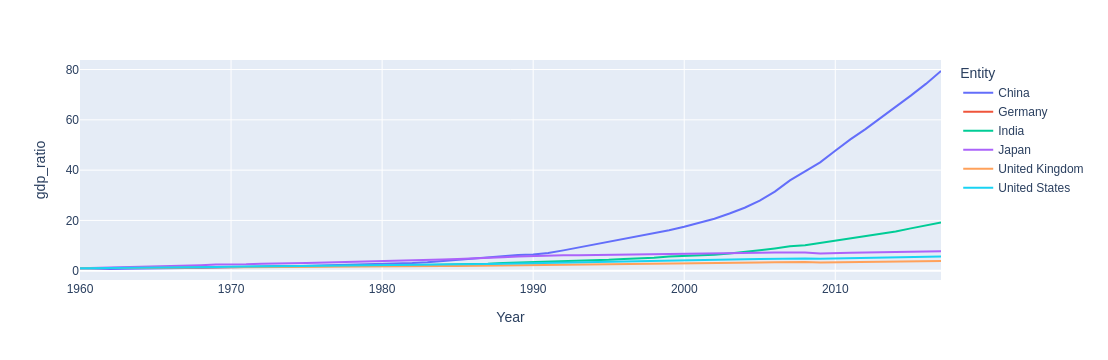

In [101]:
px.line(top6_including_gdp_ratio, x = "Year", y = "gdp_ratio", color = "Entity")

In [102]:
# Plot only the countries with large gdp growth since 1960

In [103]:
df_by_entity_and_year = df.set_index(["Entity", "Year"])
gdp1960_values_by_entity = df.query("Year == 1960").set_index(["Entity"])
df_by_entity_and_year["gdp_ratio"] = df_by_entity_and_year["gdp"] / gdp1960_values_by_entity["gdp"]
df_with_gdp_ratio = df_by_entity_and_year.reset_index()
df_with_gdp_ratio

,Entity,Year,Code,GDP (constant 2010 US$),gdp,gdp_ratio
0,Afghanistan,2002,AFG,8.013233e+09,8.013233,NaN
1,Afghanistan,2003,AFG,8.689884e+09,8.689884,NaN
2,Afghanistan,2004,AFG,8.781610e+09,8.781610,NaN
3,Afghanistan,2005,AFG,9.762979e+09,9.762979,NaN
4,Afghanistan,2006,AFG,1.030523e+10,10.305228,NaN
...,...,...,...,...,...,...
8864,Zimbabwe,2013,ZWE,1.418193e+10,14.181927,4.216605
8865,Zimbabwe,2014,ZWE,1.448359e+10,14.483588,4.306296
8866,Zimbabwe,2015,ZWE,1.472830e+10,14.728302,4.379055
8867,Zimbabwe,2016,ZWE,1.481899e+10,14.818986,4.406017


In [104]:
df_with_gdp_ratio = df_with_gdp_ratio.dropna()
df_with_gdp_ratio

,Entity,Year,Code,GDP (constant 2010 US$),gdp,gdp_ratio
54,Algeria,1960,DZA,2.743440e+10,27.434399,1.000000
55,Algeria,1961,DZA,2.370183e+10,23.701828,0.863946
56,Algeria,1962,DZA,1.903611e+10,19.036113,0.693878
57,Algeria,1963,DZA,2.556811e+10,25.568114,0.931973
58,Algeria,1964,DZA,2.706114e+10,27.061141,0.986395
...,...,...,...,...,...,...
8864,Zimbabwe,2013,ZWE,1.418193e+10,14.181927,4.216605
8865,Zimbabwe,2014,ZWE,1.448359e+10,14.483588,4.306296
8866,Zimbabwe,2015,ZWE,1.472830e+10,14.728302,4.379055
8867,Zimbabwe,2016,ZWE,1.481899e+10,14.818986,4.406017


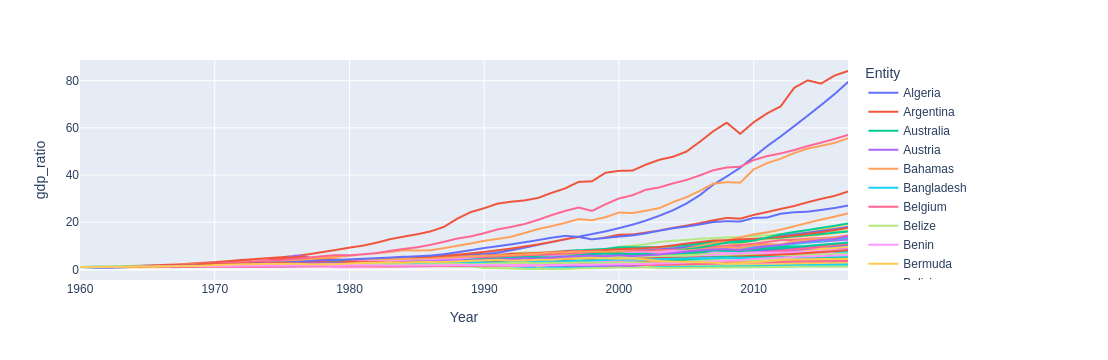

In [105]:
px.line(df_with_gdp_ratio, x = "Year", y = "gdp_ratio", color = "Entity")

In [106]:
df_with_gdp_ratio.query("Year == 2017 and gdp_ratio > 10")

,Entity,Year,Code,GDP (constant 2010 US$),gdp,gdp_ratio
638,Bangladesh,2017,BGD,1.799922e+11,179.992152,10.076512
826,Belize,2017,BLZ,1.616833e+09,1.616833,16.375388
1116,Botswana,2017,BWA,1.724066e+10,17.240661,84.096474
1314,Burkina Faso,2017,BFA,1.321529e+10,13.215294,11.456717
1783,China,2017,CHN,1.016101e+13,10161.012759,79.421294
1841,Colombia,2017,COL,3.729359e+11,372.935922,10.224493
1995,Costa Rica,2017,CRI,4.803727e+10,48.037269,12.615259
2409,Dominican Republic,2017,DOM,7.701718e+10,77.017184,17.620514
2525,Egypt,2017,EGY,2.717216e+11,271.721622,15.947716
3789,India,2017,IND,2.629542e+12,2629.542212,19.229343


In [107]:
def max_gdp_ratio_gt_10(s):
    max_gdp_ratio = max(s["gdp_ratio"])
    return max_gdp_ratio > 10

In [108]:
ratio_greater_than_10 = df_with_gdp_ratio.groupby("Entity").filter(max_gdp_ratio_gt_10)
ratio_greater_than_10

,Entity,Year,Code,GDP (constant 2010 US$),gdp,gdp_ratio
581,Bangladesh,1960,BGD,1.786255e+10,17.862545,1.000000
582,Bangladesh,1961,BGD,1.894469e+10,18.944687,1.060582
583,Bangladesh,1962,BGD,1.997775e+10,19.977747,1.118415
584,Bangladesh,1963,BGD,1.988667e+10,19.886669,1.113317
585,Bangladesh,1964,BGD,2.206481e+10,22.064814,1.235256
...,...,...,...,...,...,...
8205,Turkey,2013,TUR,9.750871e+11,975.087052,11.178871
8206,Turkey,2014,TUR,1.025467e+12,1025.466785,11.756449
8207,Turkey,2015,TUR,1.087876e+12,1087.875531,12.471933
8208,Turkey,2016,TUR,1.122512e+12,1122.511655,12.869019


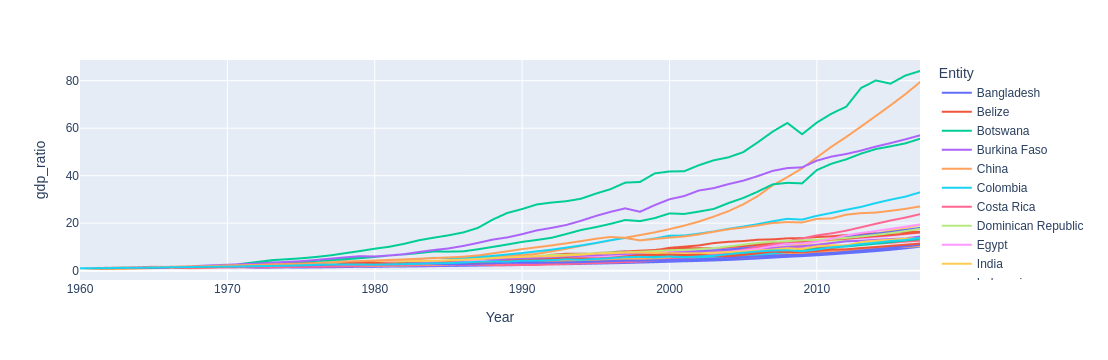

In [109]:
px.line(ratio_greater_than_10, y = "gdp_ratio", x = "Year", color = "Entity")

In [110]:
ec = ["China", "India", "United States"]
ey = [1960, 1990, 2017]
df_with_gdp_ratio.query("Entity in @ec and Year in @ey")

,Entity,Year,Code,GDP (constant 2010 US$),gdp,gdp_ratio
1726,China,1960,CHN,1.279381e+11,127.938142,1.000000
1756,China,1990,CHN,8.295620e+11,829.561968,6.484086
1783,China,2017,CHN,1.016101e+13,10161.012759,79.421294
3732,India,1960,IND,1.367463e+11,136.746336,1.000000
3762,India,1990,IND,4.665332e+11,466.533191,3.411669
3789,India,2017,IND,2.629542e+12,2629.542212,19.229343
8437,United States,1960,USA,3.078071e+12,3078.071080,1.000000
8467,United States,1990,USA,9.064414e+12,9064.413765,2.944836
8494,United States,2017,USA,1.730498e+13,17304.984279,5.622022
